<a href="https://colab.research.google.com/github/erdilix/nma-compneu2026/blob/main/projects/behavior_and_theory/earth_laquitaine_circular_fit_ext.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



note:
- I initially made this one for learning about how to compare different types of model via AIC + see how more advance model works, but the content of this notebook is not yet verified.
- from let llm read laquitaine's matlab code and compare it to "the statistic circular model" in this notebook: my "static circular" model didn't includede cardinal prior (kcardinal), seperate motor noise (kmotor), and fat tail prior (weightTail) like the original simple baysian model from laquitaine's work, so its simpler than his work.

gaps:
- i made a very simple non-circular model in a [different notebook](https://colab.research.google.com/github/erdilix/nma-compneu2026/blob/main/projects/behavior_and_theory/earth_laquitaine_fit_simple.ipynb), is it valid to compare a non-circular ver. with other models?
- from AI: if we have different pipeline, even with the same type of model + same k, there are many different factors that makes AIC different.




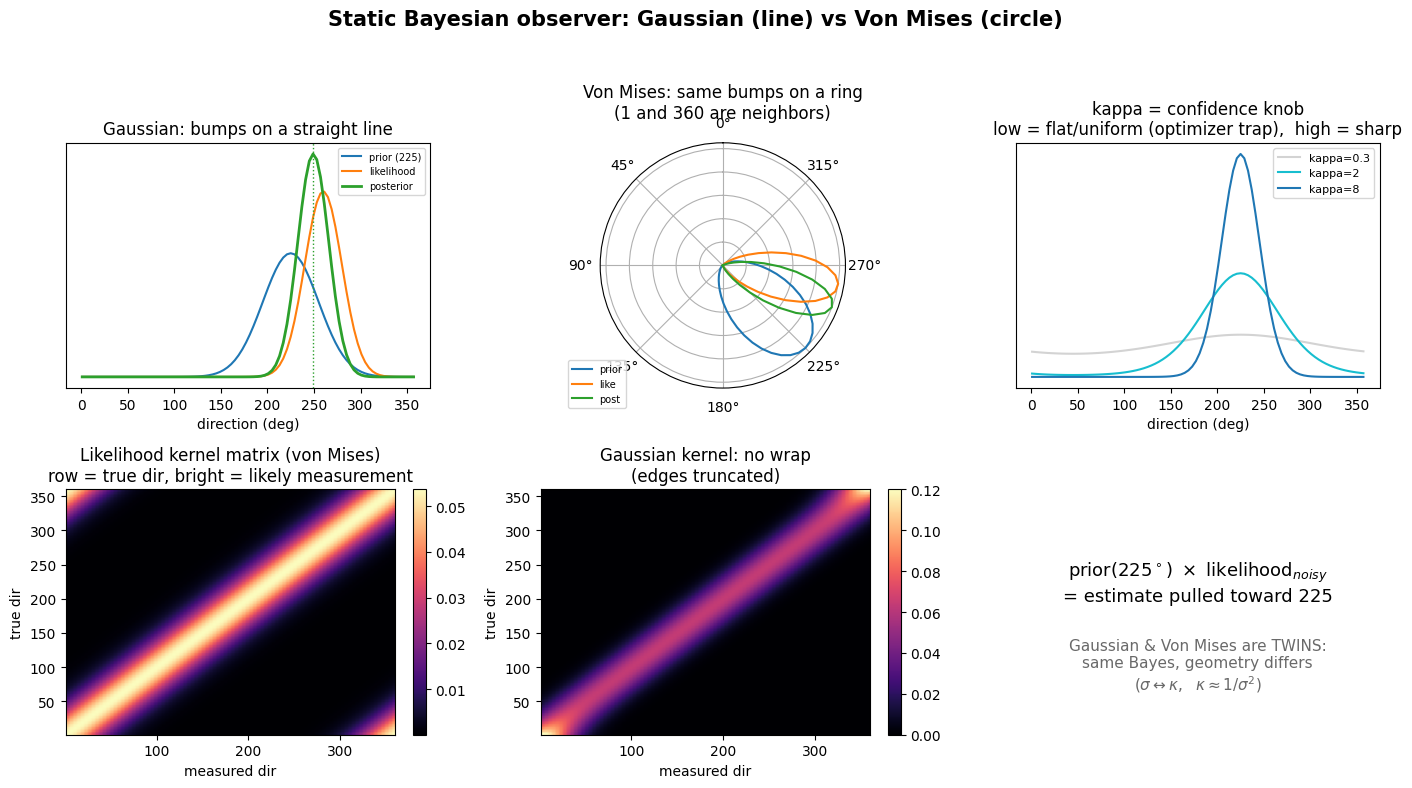

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import i0  # von Mises normalizer; if no scipy, see note below

# ---------- helpers ----------
def gaussian(x, mu, sig):
    v = np.exp(-0.5 * ((x - mu) / sig) ** 2)
    return v / v.sum()

def vonmises(deg, mu, kappa):
    d = np.deg2rad(deg - mu)
    v = np.exp(kappa * np.cos(d))
    return v / v.sum()

x = np.arange(1, 361, 4)          # direction grid (deg), same as notebook
mu = 225                           # prior mean

fig = plt.figure(figsize=(14, 8))
fig.suptitle("Static Bayesian observer: Gaussian (line) vs Von Mises (circle)",
             fontsize=15, fontweight="bold")

# ---------- (A) LINE vs RING : same Bayes, different geometry ----------
axL = fig.add_subplot(2, 3, 1)
prior = gaussian(x, mu, 30)
like  = gaussian(x, 260, 20)                 # a noisy measurement at 260
post  = prior * like; post /= post.sum()
axL.plot(x, prior, label="prior (225)", color="tab:blue")
axL.plot(x, like,  label="likelihood",  color="tab:orange")
axL.plot(x, post,  label="posterior",   color="tab:green", lw=2)
axL.axvline(x[post.argmax()], color="tab:green", ls=":", lw=1)
axL.set_title("Gaussian: bumps on a straight line")
axL.set_xlabel("direction (deg)"); axL.set_yticks([]); axL.legend(fontsize=7)

axR = fig.add_subplot(2, 3, 2, projection="polar")
th = np.deg2rad(x)
pr = vonmises(x, mu, 4)
lk = vonmises(x, 260, 9)
po = pr * lk; po /= po.sum()
for vals, c, lbl in [(pr, "tab:blue", "prior"), (lk, "tab:orange", "like"),
                     (po, "tab:green", "post")]:
    axR.plot(th, vals / vals.max(), color=c, label=lbl)
axR.set_title("Von Mises: same bumps on a ring\n(1 and 360 are neighbors)", pad=18)
axR.set_yticklabels([]); axR.set_theta_zero_location("N"); axR.legend(fontsize=7, loc="lower left", bbox_to_anchor=(-0.15, -0.1))

# ---------- (B) KAPPA KNOB : confidence dial ----------
axK = fig.add_subplot(2, 3, 3)
for kappa, c in [(0.3, "lightgray"), (2, "tab:cyan"), (8, "tab:blue")]:
    axK.plot(x, vonmises(x, mu, kappa), color=c, label=f"kappa={kappa}")
axK.set_title("kappa = confidence knob\nlow = flat/uniform (optimizer trap),  high = sharp")
axK.set_xlabel("direction (deg)"); axK.set_yticks([]); axK.legend(fontsize=8)

# ---------- (C) KERNEL MATRIX heatmap (von Mises) : wrapping diagonal ----------
axM = fig.add_subplot(2, 3, 4)
d = np.deg2rad(x[:, None] - x[None, :])
K = np.exp(4 * np.cos(d)); K /= K.sum(1, keepdims=True)
im = axM.imshow(K, origin="lower", aspect="auto", cmap="magma",
                extent=[1, 360, 1, 360])
axM.set_title("Likelihood kernel matrix (von Mises)\nrow = true dir, bright = likely measurement")
axM.set_xlabel("measured dir"); axM.set_ylabel("true dir")
fig.colorbar(im, ax=axM, fraction=0.046)

# ---------- (D) same heatmap Gaussian : diagonal does NOT wrap ----------
axMg = fig.add_subplot(2, 3, 5)
dg = x[:, None] - x[None, :]
Kg = np.exp(-0.5 * (dg / 25) ** 2); Kg /= Kg.sum(1, keepdims=True)
img = axMg.imshow(Kg, origin="lower", aspect="auto", cmap="magma",
                  extent=[1, 360, 1, 360])
axMg.set_title("Gaussian kernel: no wrap\n(edges truncated)")
axMg.set_xlabel("measured dir"); axMg.set_ylabel("true dir")
fig.colorbar(img, ax=axMg, fraction=0.046)

# ---------- (E) one-liner Bayes cartoon ----------
axT = fig.add_subplot(2, 3, 6); axT.axis("off")
axT.text(0.5, 0.62,
         r"prior$(225^\circ)\ \times\ $likelihood$_{noisy}$" "\n= estimate pulled toward 225",
         ha="center", va="center", fontsize=13)
axT.text(0.5, 0.28,
         "Gaussian & Von Mises are TWINS:\nsame Bayes, geometry differs\n"
         r"($\sigma \leftrightarrow \kappa,\ \ \kappa \approx 1/\sigma^2$)",
         ha="center", va="center", fontsize=11, color="dimgray")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("bayes_infographic.png", dpi=150, bbox_inches="tight")
plt.show()


# Fitting Bayesian observer models to real Laquitaine data

Companion to `earth_laquitaine_gen_ext.ipynb`. There the three models (static, static-with-warm-up, online) were *generative* — they output one MAP estimate per trial. To **fit them to real human data** we need a likelihood `P(estimate | stimulus, params)`, so here each model is made **probabilistic**:

- **von Mises** prior and likelihood (directions are circular),
- the latent measurement is **marginalized out** (W3D2 Tutorial 3),
- a **lapse** term removes zero-probabilities.

Then we fit free parameters by minimizing the **negative log likelihood (NLL)** and compare the three models with **AIC** — the static-vs-online test from the Laquitaine template.

**Plan:** load data → build the von Mises observer → recover parameters from *synthetic* data (sanity check) → fit all three models to one subject/one prior block → compare AIC.

In [2]:
# @title Dependencies + data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import vonmises  # noqa: F401 (kept for reference)
from scipy.optimize import minimize
import os, requests

URL = "https://github.com/steevelaquitaine/projInference/raw/gh-pages/data/csv/data01_direction4priors.csv"
CSV = "data01_direction4priors.csv"
if not os.path.exists(CSV):
    r = requests.get(URL)
    assert r.status_code == 200, "download failed; contact steeve.laquitaine@epfl.ch"
    open(CSV, "wb").write(r.content)

data = pd.read_csv(CSV)
print(data.shape)
data[["subject_id", "prior_std", "motion_coherence", "motion_direction"]].head()

(83213, 16)


,subject_id,prior_std,motion_coherence,motion_direction
0,1,10,0.12,225
1,1,10,0.12,225
2,1,10,0.06,235
3,1,10,0.06,225
4,1,10,0.24,215


## The von Mises Bayesian observer

Everything lives on a coarse direction grid (`GRID_STEP` deg) to keep fitting fast — shrink the step for accuracy, grow it for speed.

- `kernel(kappa)` — an `n×n` matrix whose row *i* is a von Mises centred on grid point *i*. Because von Mises depends only on the angular difference, this single matrix serves as **both** the likelihood (given a measurement) and `P(measurement | stimulus)`.
- `response_prob` — for a fixed prior, each possible measurement yields a deterministic MAP response; we sum `P(measurement | stimulus)` over all measurements landing on each response, then mix in the lapse. This is the marginalization step.

In [3]:
# @title Grid + observer building blocks
GRID_STEP = 4                      # deg; smaller = more accurate, slower
xg = np.arange(1, 361, GRID_STEP)  # direction grid
n = len(xg)

def to_idx(val):
    return np.clip(np.round((np.asarray(val, float) - xg[0]) / GRID_STEP).astype(int), 0, n - 1)

def sig(z):    return 1.0 / (1.0 + np.exp(-z))
def logit(p):  return np.log(p / (1.0 - p))

def signed_diff(target, current):
    """smallest signed angular difference target - current (deg)."""
    return ((target - current + 180) % 360) - 180

def circular_mean(deg):
    r = np.deg2rad(deg)
    return np.degrees(np.arctan2(np.sin(r).sum(), np.cos(r).sum())) % 360

def kernel(kappa):
    """n x n von Mises kernel; row i is a distribution centred on xg[i]."""
    d = np.deg2rad(xg[:, None] - xg[None, :])
    K = np.exp(kappa * np.cos(d))
    return K / K.sum(1, keepdims=True)

def vm_row(mu_deg, kappa):
    d = np.deg2rad(mu_deg - xg)
    v = np.exp(kappa * np.cos(d))
    return v / v.sum()

def response_prob(prior, L, stim_idx, lapse):
    """P(estimate | stimulus) as a length-n vector, marginalizing over measurement."""
    R = (prior[None, :] * L).argmax(1)              # MAP response idx per measurement
    resp = np.bincount(R, weights=L[stim_idx], minlength=n)
    resp = (1 - lapse) * resp / resp.sum() + lapse / n
    return resp

## Peek inside: what `kernel(kappa)` actually is

Before fitting anything, let's *see* the building blocks so the later code is intuitive. `kernel(kappa)` is an `n×n` matrix — row *i* is a von Mises bump centred on grid direction *i*. Two facts to confirm by eye:

- every row is the **same bump, just shifted** (von Mises depends only on the angular difference), and
- the matrix is **symmetric**, which is exactly why one matrix is simultaneously the likelihood (read a column) and `P(measurement | stimulus)` (read a row).

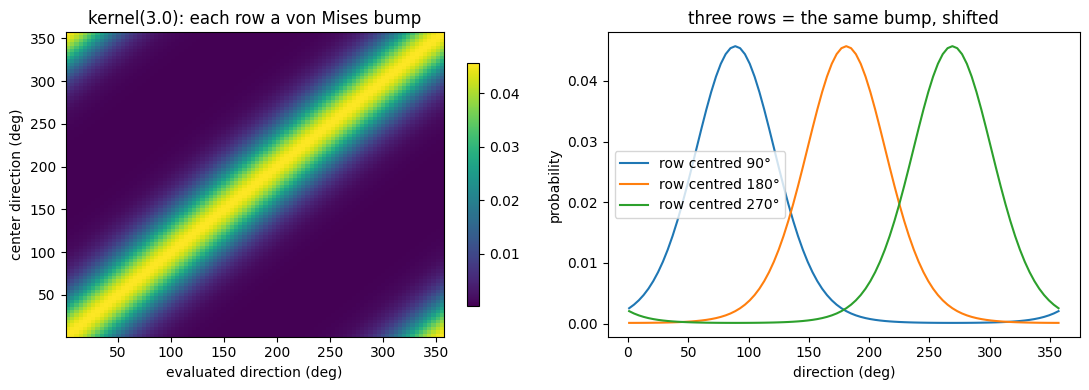

max |row_i - col_i| = 6.938893903907228e-18 (≈0 -> symmetric -> likelihood = P(meas|stim))
higher kappa = sharper bump: kappa=1 peak 0.0239 | kappa=8 peak 0.0775


In [4]:
# @title Visualize the kernel matrix + a few rows
K = kernel(3.0)                      # concentration kappa = 3
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

im = ax[0].imshow(K, origin="lower", extent=[xg[0], xg[-1], xg[0], xg[-1]], aspect="auto")
ax[0].set_title("kernel(3.0): each row a von Mises bump")
ax[0].set_xlabel("evaluated direction (deg)")
ax[0].set_ylabel("center direction (deg)")
fig.colorbar(im, ax=ax[0], shrink=0.8)

for c_deg in [90, 180, 270]:
    i = to_idx(c_deg)
    ax[1].plot(xg, K[i], label=f"row centred {c_deg}\u00b0")
ax[1].set_title("three rows = the same bump, shifted")
ax[1].set_xlabel("direction (deg)"); ax[1].set_ylabel("probability")
ax[1].legend()
plt.tight_layout(); plt.show()

# symmetry / dual-role check: row i vs column i
i = to_idx(180)
print("max |row_i - col_i| =", np.abs(K[i] - K[:, i]).max(),
      "(≈0 -> symmetric -> likelihood = P(meas|stim))")
print("higher kappa = sharper bump:",
      "kappa=1 peak", kernel(1.0)[i].max().round(4),
      "| kappa=8 peak", kernel(8.0)[i].max().round(4))

## Peek inside: the prior `vm_row(225, kappa_prior)`

The prior is one von Mises centred on 225°. `kappa_prior` is its **width knob**: big kappa = narrow, confident belief that pulls estimates hard toward 225°; small kappa = broad, weak belief. This single number is what the fit later estimates from behaviour (`kappa ≈ 1/σ²`).

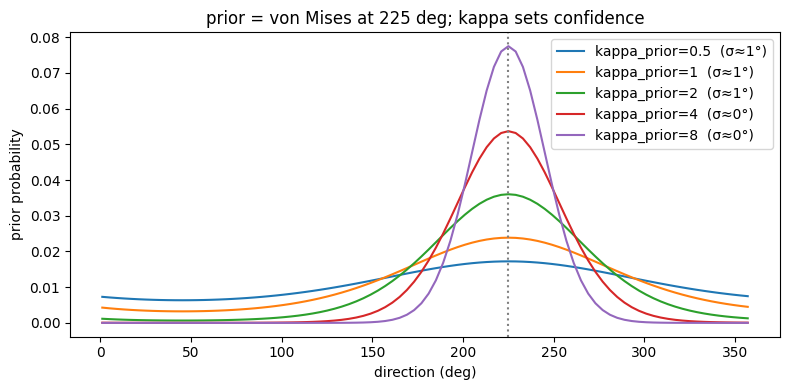

In [5]:
# @title Prior shape for several kappa_prior
plt.figure(figsize=(8, 4))
for kp in [0.5, 1, 2, 4, 8]:
    p = vm_row(225, kp)
    plt.plot(xg, p, label=f"kappa_prior={kp}  (\u03c3\u2248{1/np.sqrt(kp):.0f}\u00b0)")
plt.axvline(225, color="gray", ls=":")
plt.title("prior = von Mises at 225 deg; kappa sets confidence")
plt.xlabel("direction (deg)"); plt.ylabel("prior probability")
plt.legend(); plt.tight_layout(); plt.show()

## Peek inside: one Bayesian trial (prior × likelihood → MAP bias)

Bayes rule on the grid: `posterior ∝ prior × likelihood`, and the readout is the MAP (argmax). With the prior at 225°, the posterior peak sits **between** the sensory measurement and 225° — the estimate is *biased toward the prior*. Weakening the sensory reliability (`kappa_llh`) drags it further toward 225°. This is the single-trial version of the whole effect.

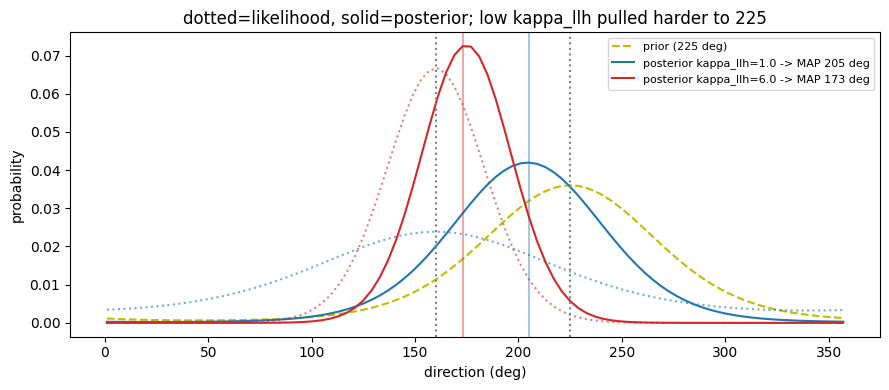

In [6]:
# @title One trial: how the posterior gets pulled toward the prior
meas_deg = 160.0            # this trial's noisy measurement
kp = 2.0                    # prior concentration
prior = vm_row(225, kp)

plt.figure(figsize=(9, 4))
plt.plot(xg, prior, "--", color=[0.75, 0.75, 0], label="prior (225 deg)")
for kllh, col in [(1.0, "tab:blue"), (6.0, "tab:red")]:
    like = vm_row(meas_deg, kllh)                 # likelihood centred on measurement
    post = prior * like; post = post / post.sum() # Bayes: multiply + normalize
    est = xg[post.argmax()]                        # MAP readout
    plt.plot(xg, like, ":", color=col, alpha=0.6)
    plt.plot(xg, post, "-", color=col, label=f"posterior kappa_llh={kllh} -> MAP {est:.0f} deg")
    plt.axvline(est, color=col, ls="-", alpha=0.4)
plt.axvline(meas_deg, color="gray", ls=":"); plt.axvline(225, color="gray", ls=":")
plt.title("dotted=likelihood, solid=posterior; low kappa_llh pulled harder to 225")
plt.xlabel("direction (deg)"); plt.ylabel("probability")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## Peek inside: `response_prob` marginalizes the hidden measurement

We never observe the subject's internal measurement — only their final estimate. So the likelihood used for fitting is `P(estimate | stimulus)`, built by summing over every measurement that could have produced each MAP response, then adding a lapse floor. Below: the same stimulus at three sensory reliabilities. Lower `kappa_llh` (lower coherence) ⇒ the response distribution slides toward the 225° prior. That coherence-dependent bias is the experimental signature the fit is chasing.

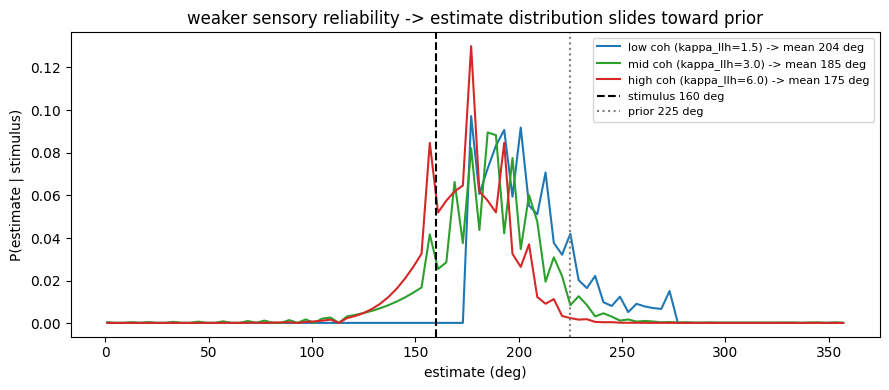

In [7]:
# @title P(estimate | stimulus) at three coherences (kappa_llh)
stim_deg = 160.0
s_i = to_idx(stim_deg)
kp = 2.0
prior = vm_row(225, kp)

plt.figure(figsize=(9, 4))
for kllh, lab, col in [(1.5, "low coh", "tab:blue"),
                       (3.0, "mid coh", "tab:green"),
                       (6.0, "high coh", "tab:red")]:
    L = kernel(kllh)
    resp = response_prob(prior, L, s_i, lapse=0.02)
    mean_est = circular_mean(np.repeat(xg, np.round(resp * 10000).astype(int)))
    plt.plot(xg, resp, color=col, label=f"{lab} (kappa_llh={kllh}) -> mean {mean_est:.0f} deg")
plt.axvline(stim_deg, color="k", ls="--", label=f"stimulus {stim_deg:.0f} deg")
plt.axvline(225, color="gray", ls=":", label="prior 225 deg")
plt.title("weaker sensory reliability -> estimate distribution slides toward prior")
plt.xlabel("estimate (deg)"); plt.ylabel("P(estimate | stimulus)")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## Peek inside: how the *online* prior mean drifts (delta rule)

The online model has no fixed prior — after each trial it nudges the prior mean toward the stimulus just seen: `mu <- mu + LR · signed_diff(stim, mu)`. Small `LR` = sluggish (near-static); large `LR` = the prior chases recent stimuli. This delta rule is the only structural difference from the static model, and it is exactly the update inside `nll_online` below.

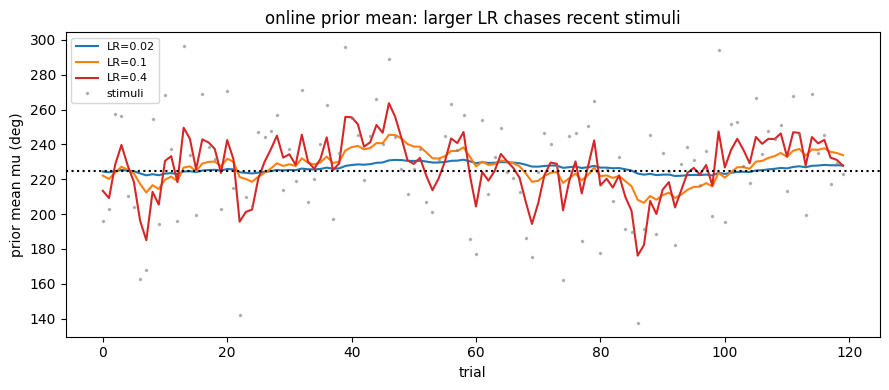

In [8]:
# @title Prior-mean trajectory under the delta rule
rng = np.random.default_rng(1)
stims = (225 + rng.vonmises(0, 4, size=120) * 180 / np.pi) % 360   # fake stimulus stream near 225

plt.figure(figsize=(9, 4))
for lr, col in [(0.02, "tab:blue"), (0.1, "tab:orange"), (0.4, "tab:red")]:
    mu, traj = 225.0, []
    for s in stims:
        mu = (mu + lr * signed_diff(s, mu)) % 360
        traj.append(mu)
    plt.plot(traj, color=col, label=f"LR={lr}")
plt.plot(stims, ".", color="gray", ms=3, alpha=0.5, label="stimuli")
plt.axhline(225, color="k", ls=":")
plt.title("online prior mean: larger LR chases recent stimuli")
plt.xlabel("trial"); plt.ylabel("prior mean mu (deg)")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## Negative log likelihood for each model

Free parameters (fit in unconstrained space, then transformed back):

| Model | prior each trial | free params |
|---|---|---|
| **static** | `vm(225, kappa_prior)`, fixed | `kappa_llh`×3 coherence, `kappa_prior`, `lapse` |
| **online** | mean drifts toward each stimulus (delta rule, rate `LR`) | static + `LR` |
| **warm-up** | flat until trial `N`, then `vm(circular_mean(first N stimuli), kappa_prior)` | static + `N` (grid-searched) |

There is **no trial feedback** in this task, so the online model updates its prior from the **stimulus** the subject saw.

In [9]:
# @title NLL functions
def unpack(theta):
    k = np.exp(theta[:3])          # kappa_llh per coherence level
    kp = np.exp(theta[3])          # kappa_prior
    lap = sig(theta[4])            # lapse
    return k, kp, lap

def nll_static(theta, S, E, C):
    k, kp, lap = unpack(theta)
    prior = vm_row(225, kp)
    ll = 0.0
    for c in range(3):
        L = kernel(k[c])
        R = (prior[None, :] * L).argmax(1)
        m = C == c
        for s_i in np.unique(S[m]):                 # cache response dist per unique stimulus
            resp = np.bincount(R, weights=L[s_i], minlength=n)
            resp = (1 - lap) * resp / resp.sum() + lap / n
            e = E[m & (S == s_i)]
            ll += np.log(resp[e] + 1e-12).sum()
    return -ll

def nll_online(theta, S, E, C, Sdeg, order):
    k, kp, lap = unpack(theta)
    lr = sig(theta[5])
    Ls = [kernel(k[c]) for c in range(3)]
    mu = 225.0
    ll = 0.0
    for t in order:
        L = Ls[C[t]]
        prior = vm_row(mu, kp)
        resp = response_prob(prior, L, S[t], lap)
        ll += np.log(resp[E[t]] + 1e-12)
        mu = (mu + lr * signed_diff(Sdeg[t], mu)) % 360   # update from stimulus
    return -ll

def nll_warmup(theta, S, E, C, Sdeg, order, N):
    k, kp, lap = unpack(theta)
    mu = circular_mean(Sdeg[order[:N]])
    Ls = [kernel(k[c]) for c in range(3)]
    prior_fix = vm_row(mu, kp)
    flat = np.ones(n) / n
    Rfix = [(prior_fix[None, :] * Ls[c]).argmax(1) for c in range(3)]
    Rflat = [(flat[None, :] * Ls[c]).argmax(1) for c in range(3)]
    ll = 0.0
    for i, t in enumerate(order):
        L = Ls[C[t]]
        R = Rflat[C[t]] if i < N else Rfix[C[t]]
        resp = np.bincount(R, weights=L[S[t]], minlength=n)
        resp = (1 - lap) * resp / resp.sum() + lap / n
        ll += np.log(resp[E[t]] + 1e-12)
    return -ll

def simulate_static(theta, S, C, rng):
    """generate synthetic estimates from the static model (for parameter recovery)."""
    k, kp, lap = unpack(theta)
    prior = vm_row(225, kp)
    Ls = [kernel(k[c]) for c in range(3)]
    Rs = [(prior[None, :] * Ls[c]).argmax(1) for c in range(3)]
    E = np.zeros(len(S), int)
    for i in range(len(S)):
        c = C[i]
        resp = np.bincount(Rs[c], weights=Ls[c][S[i]], minlength=n)
        resp = (1 - lap) * resp / resp.sum() + lap / n
        E[i] = rng.choice(n, p=resp)
    return E

def fit(nll, x0, args, maxiter=1500):
    return minimize(nll, x0, args=args, method="Nelder-Mead",
                    options={"maxiter": maxiter, "xatol": 1e-2, "fatol": 1e-2})

# @title Non-circular (Gaussian) STATIC model -- the one baseline to compare
# Straight-line twin of the von Mises static model: every von Mises -> Gaussian,
# every circular op -> linear. Same grid, same PMF likelihood resp[e], same lapse,
# same k = 5 (3 sensory widths + 1 prior width + lapse). Scoring it the SAME way
# as the circular models is what makes the AIC numbers comparable -- the only
# thing that changes between this row and "static (circular)" is the geometry
# (line vs circle / Gaussian vs von Mises), so their AIC gap isolates WRAP.
# Note: sigma is the inverse feel of kappa (kappa ~ 1/sigma^2); unpack() just
# exponentiates, so here read its output as SIGMA (deg), not kappa.

def gauss_kernel(sigma):
    """n x n Gaussian kernel; row i centred on xg[i], no wrap."""
    d = xg[:, None] - xg[None, :]
    K = np.exp(-0.5 * (d / sigma) ** 2)
    return K / K.sum(1, keepdims=True)

def g_row(mu_deg, sigma):
    v = np.exp(-0.5 * ((mu_deg - xg) / sigma) ** 2)
    return v / v.sum()

def nll_static_gauss(theta, S, E, C):
    """Non-circular static Bayesian observer; identical likelihood to nll_static."""
    s, sp, lap = unpack(theta)          # exp(theta) read as sigma_llh x3, sigma_prior
    prior = g_row(225, sp)
    ll = 0.0
    for c in range(3):
        L = gauss_kernel(s[c])
        R = (prior[None, :] * L).argmax(1)
        m = C == c
        for s_i in np.unique(S[m]):
            resp = np.bincount(R, weights=L[s_i], minlength=n)
            resp = (1 - lap) * resp / resp.sum() + lap / n
            e = E[m & (S == s_i)]
            ll += np.log(resp[e] + 1e-12).sum()
    return -ll

## Prepare one subject, one prior block

We fit **subject 1**, the **80° prior block** (widest prior → most room for the models to differ), across its three coherences. Trials are put in temporal order for the online / warm-up models. Extend later by looping over subjects and `prior_std`.

In [10]:
# @title Build arrays for subject 1, prior_std = 80
SUBJECT_ID = 1
PRIOR_STD = 80

sub = data[(data.subject_id == SUBJECT_ID) & (data.prior_std == PRIOR_STD)].copy()
sub = sub.dropna(subset=["estimate_x", "estimate_y"])
sub = sub.sort_values(["session_id", "run_id", "trial_index"]).reset_index(drop=True)

est_deg = np.round(np.degrees(np.arctan2(sub.estimate_y.values, sub.estimate_x.values)) % 360)
Sdeg = sub.motion_direction.values.astype(float)
coh = sub.motion_coherence.values
coh_levels = np.sort(np.unique(coh))          # e.g. [0.06, 0.12, 0.24]

S = to_idx(Sdeg)
E = to_idx(est_deg)
C = np.searchsorted(coh_levels, coh)
order = np.arange(len(S))

print(f"{len(S)} trials | coherences {coh_levels} | unique stimuli {np.unique(Sdeg)}")

3506 trials | coherences [0.06 0.12 0.24] | unique stimuli [  5.  15.  25.  35.  45.  55.  65.  75.  85.  95. 105. 115. 125. 135.
 145. 155. 165. 175. 185. 195. 205. 215. 225. 235. 245. 255. 265. 275.
 285. 295. 305. 315. 325. 335. 345. 355.]


## Sanity check: recover known parameters from synthetic data

Before trusting a fit on real data, confirm the fitter can recover parameters it generated itself (Tutorial 3's rule). We simulate estimates from the static model with **known** parameters on subject 1's actual stimulus sequence, then fit and compare.

In [11]:
# @title Parameter recovery (static model)
rng = np.random.default_rng(0)
true_theta = np.array([np.log(1.5), np.log(3.0), np.log(6.0),  # kappa_llh (rises with coherence)
                       np.log(2.0),                            # kappa_prior
                       logit(0.05)])                           # lapse
E_syn = simulate_static(true_theta, S, C, rng)

x0 = np.array([np.log(1.0), np.log(2.0), np.log(4.0), np.log(1.5), logit(0.1)])
res_syn = fit(nll_static, x0, (S, E_syn, C))

def show(theta):
    k, kp, lap = unpack(theta)
    return f"kllh={np.round(k,2)}  kprior={kp:.2f}  lapse={lap:.3f}"

print("true     :", show(true_theta))
print("recovered:", show(res_syn.x))

true     : kllh=[1.5 3.  6. ]  kprior=2.00  lapse=0.050
recovered: kllh=[1.   2.08 4.83]  kprior=1.59  lapse=0.150


## Fit the models to the real data & compare with AIC

`AIC = 2k + 2*NLL`; lower is better. `k` = number of free parameters (static 5, online 6, warm-up 6 counting the searched `N`).

Added here: **one non-circular (Gaussian) static** model as a baseline, `k = 5`. It is fit to the **same data under the same grid PMF and lapse** as the circular models, so its AIC is comparable. Since it has the same `k` as the circular static model, the AIC gap between them is a pure NLL gap that isolates one thing: **does directional wrap matter** for this subject/block? (Subject 1's 80 deg block clusters near 225 deg, far from 0/360, so the Gaussian approximation is expected to hold -- a fair test.) See the rulebook below for the setup variables that must match for any AIC comparison, including against a teammate's model.

### Rulebook -- experiment-setup variables that affect AIC

AIC is only comparable when the setup is identical. Present this to your friend and check each row matches, or the two AIC numbers do not mean the same thing.

**Group A -- must be IDENTICAL across every compared model** (else the AIC gap is an artefact, not evidence):

| # | variable | this notebook |
|---|---|---|
| A1 | dataset slice: `subject_id`, `prior_std` block, coherences | subj 1, 80 deg block, 3 cohs |
| A2 | trial set & N (same NaN/outlier dropping, same ordering) | same `dropna`, same trials |
| A3 | response representation | discrete grid index `E` (`to_idx` of estimate) |
| A4 | likelihood measure | grid **PMF** `resp[e]` (NOT a continuous density -- the two differ by `log(GRID_STEP)` and cannot be mixed) |
| A5 | grid resolution `GRID_STEP` (=> n) | 4 deg |
| A6 | lapse floor | `(1-lap)*resp + lap/n` |
| A7 | AIC formula | plain AIC (vs AICc); pick one, use it for all |

**The one variable under test (NOT held constant here):**

- **Geometry -- circular (von Mises) vs non-circular (Gaussian).** This is exactly the thing the circular-vs-non-circular AIC gap measures, so it is the *contrast*, not a control. Everything in Group A must still match so this is the only difference.

**Group B -- counted per model, define consistently:**

- B1 `k` = number of free parameters. Count the same way for every model (static 5, online 6, warm-up 6).
- B2 fixed vs free: prior mean 225 deg is fixed by the experiment -> **not** in k. Warm-up `N` is grid-searched over the data -> a hidden degree of freedom; it is counted here as +1 (k=6). Be explicit with your friend about this choice.
- B3 model scope: this static model omits Laquitaine's `kcardinal` (cardinal prior), separate `kmotor` (motor noise), and `weightTail` (fat-tail prior). If your friend's model includes them, k and NLL differ for structural reasons -- note it before comparing.

**Group C -- must NOT leak into the number** (control for, but not real variables):

- C1 optimizer convergence (`maxiter`, `xatol`/`fatol`, start `x0`): poor convergence inflates NLL and corrupts AIC. Confirm each fit converged.
- C2 reparameterization (log / logit / sigma-vs-kappa): optimizer space only -- does **not** change NLL or AIC.
- C3 random seed: only for the synthetic parameter-recovery check, never for real-data AIC.

**One-line rule:** *same data, same N, same likelihood measure, same grid, same lapse, same AIC formula -> then and only then are two AIC numbers comparable; the only intended difference is the geometry.*

In [12]:
# @title Fit static / online / warm-up, then compare
x0s = np.array([np.log(1.0), np.log(2.0), np.log(4.0), np.log(1.5), logit(0.1)])

# static
res_static = fit(nll_static, x0s, (S, E, C))
k_static = 5
aic_static = 2 * k_static + 2 * res_static.fun

# online (warm-start from static, add LR)
x0o = np.append(res_static.x, logit(0.05))
res_online = fit(nll_online, x0o, (S, E, C, Sdeg, order))
k_online = 6
aic_online = 2 * k_online + 2 * res_online.fun

# warm-up: grid-search N, fit static-form params for each
best = None
for N in [10, 20, 40, 80]:
    r = fit(nll_warmup, res_static.x, (S, E, C, Sdeg, order, N))
    if best is None or r.fun < best[1].fun:
        best = (N, r)
N_best, res_warm = best
k_warm = 6
aic_warm = 2 * k_warm + 2 * res_warm.fun

# non-circular (Gaussian) static baseline -- same grid PMF, k=5, AIC-comparable
x0g = np.array([np.log(40.0), np.log(22.0), np.log(12.0), np.log(25.0), logit(0.1)])
res_gauss = fit(nll_static_gauss, x0g, (S, E, C))
k_gauss = 5
aic_gauss = 2 * k_gauss + 2 * res_gauss.fun

rows = [("static (circular)", k_static, res_static.fun, aic_static),
        ("static (non-circular)", k_gauss, res_gauss.fun, aic_gauss),
        ("online", k_online, res_online.fun, aic_online),
        (f"warm-up (N={N_best})", k_warm, res_warm.fun, aic_warm)]
print(f"{'model':<24}{'k':>3}{'NLL':>12}{'AIC':>12}")
for name, k, nllv, aic in rows:
    print(f"{name:<24}{k:>3}{nllv:>12.1f}{aic:>12.1f}")
winner = min(rows, key=lambda r: r[3])[0]
print(f"\nlowest AIC -> {winner}")

# delta-AIC vs the best model (dAIC): <2 tie, 4-7 moderate, >10 strong
best_aic = min(r[3] for r in rows)
print(f"\n{'model':<24}{'AIC':>10}{'dAIC':>8}")
for name, k, nllv, aic in rows:
    print(f"{name:<24}{aic:>10.1f}{aic - best_aic:>8.1f}")

# the circular vs non-circular question, direct:
d = aic_static - aic_gauss
print(f"\ncircular - non-circular AIC = {d:+.1f}"
      f"   ({'tie / fit noise' if abs(d) < 2 else 'real gap, investigate'})")


model                     k         NLL         AIC
static (circular)         5     13996.8     28003.6
static (non-circular)     5     12450.6     24911.2
online                    6     12422.4     24856.8
warm-up (N=40)            6     12863.4     25738.7

lowest AIC -> online

model                          AIC    dAIC
static (circular)          28003.6  3146.8
static (non-circular)      24911.2    54.4
online                     24856.8     0.0
warm-up (N=40)             25738.7   881.9

circular - non-circular AIC = +3092.4   (real gap, investigate)


## Read out and visualize the winning fit

Overlay the model's predicted mean estimate against the subject's data, per stimulus and coherence. A good fit tracks the data's pull toward the 225° prior, stronger at low coherence.

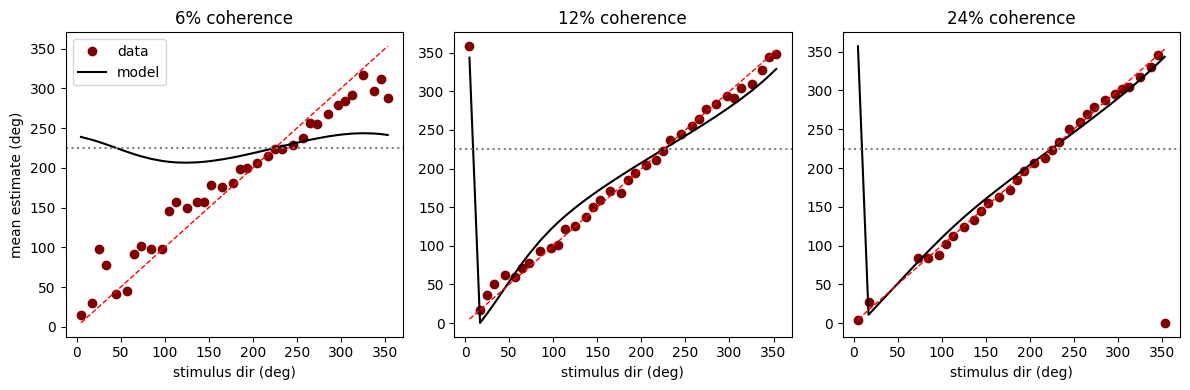

In [13]:
# @title Predicted vs observed mean estimate (static fit)
k, kp, lap = unpack(res_static.x)
prior = vm_row(225, kp)

plt.figure(figsize=(12, 4))
for c in range(3):
    L = kernel(k[c])
    R = (prior[None, :] * L).argmax(1)
    us = np.unique(S[C == c])
    pred_mean, data_mean, stim_deg = [], [], []
    for s_i in us:
        resp = np.bincount(R, weights=L[s_i], minlength=n)
        resp = (1 - lap) * resp / resp.sum() + lap / n
        pred_mean.append(circular_mean(np.repeat(xg, np.round(resp * 10000).astype(int))))
        e = E[(C == c) & (S == s_i)]
        data_mean.append(circular_mean(xg[e]))
        stim_deg.append(xg[s_i])
    ax = plt.subplot(1, 3, c + 1)
    order_s = np.argsort(stim_deg)
    stim_deg = np.array(stim_deg)[order_s]
    ax.plot(stim_deg, np.array(data_mean)[order_s], "o", color=[0.5, 0, 0], label="data")
    ax.plot(stim_deg, np.array(pred_mean)[order_s], "-", color="k", label="model")
    ax.axhline(225, color="gray", ls=":")
    ax.plot([stim_deg.min(), stim_deg.max()], [stim_deg.min(), stim_deg.max()], "r--", lw=1)
    ax.set_title(f"{int(coh_levels[c]*100)}% coherence")
    ax.set_xlabel("stimulus dir (deg)")
    if c == 0:
        ax.set_ylabel("mean estimate (deg)"); ax.legend()
plt.tight_layout(); plt.show()

## Notes & next steps

- **Scope of this demo.** One subject, one prior block. Loop over `subject_id` and `prior_std` to fit everyone; sum AIC across subjects for a group-level model comparison.
- **Grid & speed.** `GRID_STEP=4` keeps the online fit quick. Drop to 1–2° for the final numbers (slower).
- **Parameter recovery first.** If the synthetic recovery above is poor, tighten the grid or reduce free parameters before reading anything into the real-data fit.
- **Model realism.** `kappa_prior` is currently a single fitted width; the real paper also lets the prior width track the experimental `prior_std`. The online update here is a minimal delta rule on the prior mean; richer versions update the width too.
- **This is the template's core comparison.** Static vs online vs warm-up via AIC = exactly the "online vs static Bayesian" test in the Laquitaine project template (W3D2 Tutorial 3 + W1D2 Model Fitting).